In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:


file_path = "/content/SaYoPillow.csv"
# Auto detect file type
if file_path.endswith(".csv"):
    df = pd.read_csv(file_path)
elif file_path.endswith(".xlsx"):
    df = pd.read_excel(file_path)
else:
    raise ValueError("Only CSV and Excel files are supported")

print("\nDataset Loaded Successfully")
print("Shape :", df.shape)


Dataset Loaded Successfully
Shape : (630, 9)


In [ ]:

duplicates = df.duplicated().sum()
df.drop_duplicates(inplace=True)

print(f"\nDuplicates Removed : {duplicates}")


Duplicates Removed : 0


In [ ]:

for col in df.columns:

    if df[col].dtype in ['int64', 'float64']:
        df[col] = df[col].fillna(df[col].median())

    else:
        mode_value = df[col].mode()

        if len(mode_value) > 0:
            df[col] = df[col].fillna(mode_value[0])
        else:
            df[col] = df[col].fillna("Unknown")

print("\nMissing Values Handled")


Missing Values Handled


In [ ]:

numeric_cols = df.select_dtypes(include=np.number).columns

initial_rows = len(df)

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

final_rows = len(df)

print(f"\nRows Removed By IQR : {initial_rows - final_rows}")


Rows Removed By IQR : 0


In [ ]:


constant_cols = [col for col in df.columns if df[col].nunique() <= 1]

if constant_cols:
    df.drop(columns=constant_cols, inplace=True)

print("\nConstant Columns Removed :", constant_cols)


Constant Columns Removed : []


In [ ]:


df.reset_index(drop=True, inplace=True)

In [ ]:


print("\nFinal Shape :", df.shape)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())


Final Shape : (630, 9)

Missing Values After Cleaning:
sr      0
rr      0
t       0
lm      0
bo      0
rem     0
sr.1    0
hr      0
sl      0
dtype: int64



Cleaned Dataset Saved Successfully


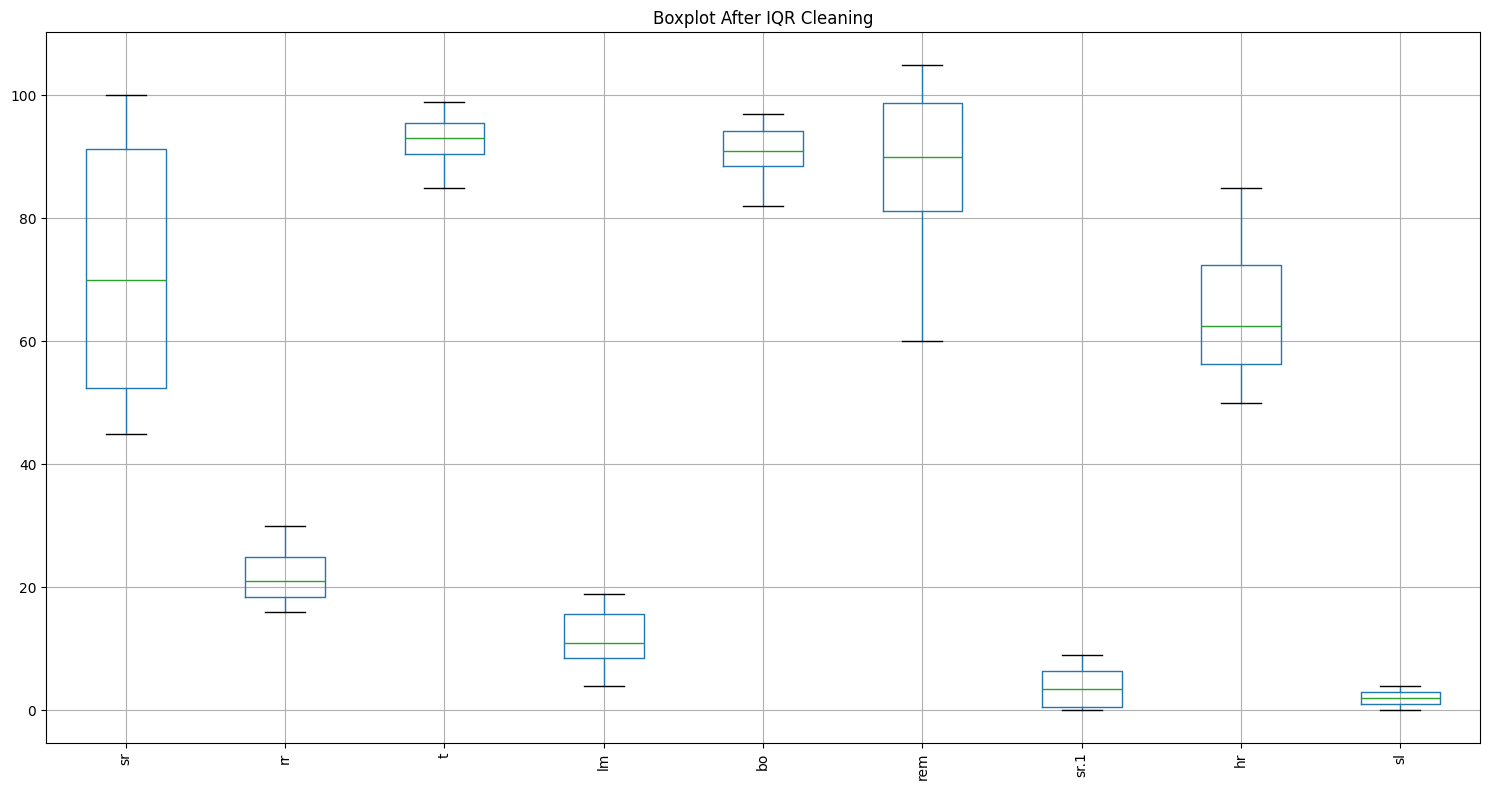

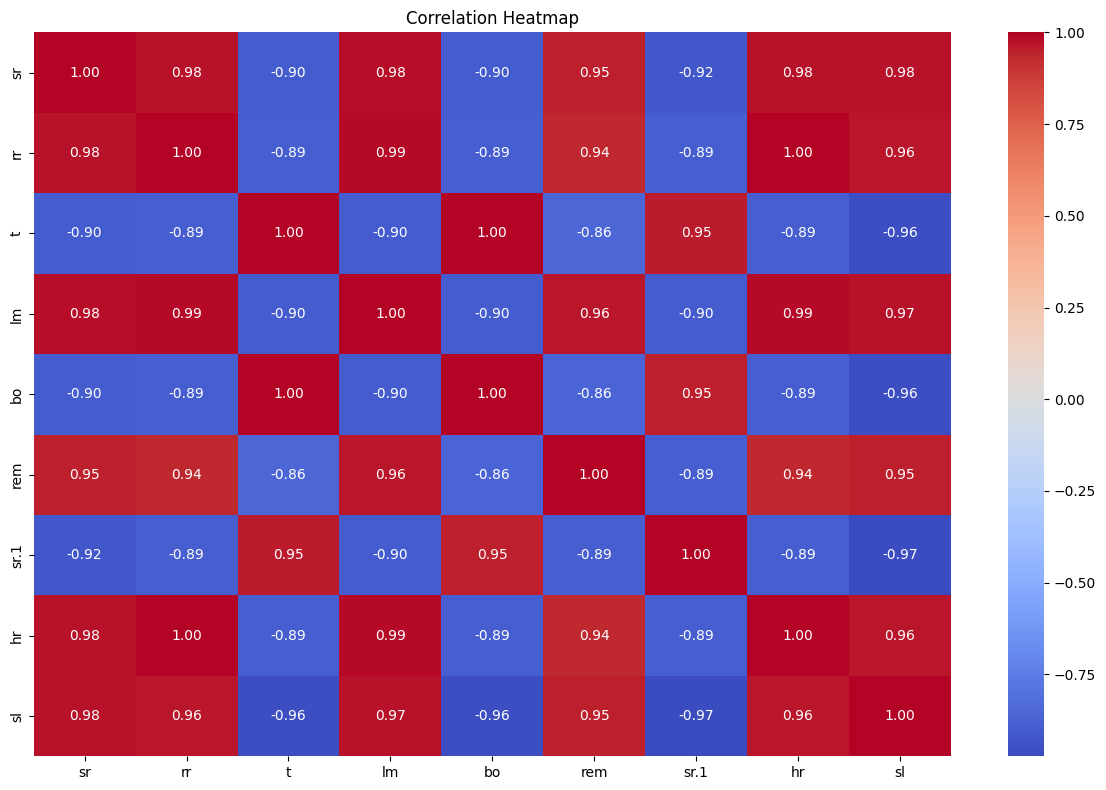


Data Cleaning Completed Successfully


In [ ]:


df.to_csv("cleaned_dataset.csv", index=False)

print("\nCleaned Dataset Saved Successfully")



if len(numeric_cols) > 0:

    plt.figure(figsize=(15,8))
    df[numeric_cols].boxplot(rot=90)
    plt.title("Boxplot After IQR Cleaning")
    plt.tight_layout()
    plt.show()



if len(numeric_cols) > 1:

    plt.figure(figsize=(12,8))
    sns.heatmap(
        df[numeric_cols].corr(),
        annot=True,
        cmap="coolwarm",
        fmt=".2f"
    )

    plt.title("Correlation Heatmap")
    plt.tight_layout()
    plt.show()

print("\nData Cleaning Completed Successfully")

In [ ]:
df = pd.read_csv("/content/cleaned_dataset.csv")
df

,sr,rr,t,lm,bo,rem,sr.1,hr,sl
0,93.800,25.680,91.840,16.600,89.840,99.60,1.840,74.20,3
1,91.640,25.104,91.552,15.880,89.552,98.88,1.552,72.76,3
2,60.000,20.000,96.000,10.000,95.000,85.00,7.000,60.00,1
3,85.760,23.536,90.768,13.920,88.768,96.92,0.768,68.84,3
4,48.120,17.248,97.872,6.496,96.248,72.48,8.248,53.12,0
...,...,...,...,...,...,...,...,...,...
625,69.600,20.960,92.960,10.960,90.960,89.80,3.440,62.40,2
626,48.440,17.376,98.064,6.752,96.376,73.76,8.376,53.44,0
627,97.504,27.504,86.880,17.752,84.256,101.88,0.000,78.76,4
628,58.640,19.728,95.728,9.728,94.592,84.32,6.728,59.32,1


In [ ]:
X = df.drop('sl', axis=1)
y = df['sl']

for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        24
           2       1.00      1.00      1.00        28
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        25

    accuracy                           1.00       126
   macro avg       1.00      1.00      1.00       126
weighted avg       1.00      1.00      1.00       126

